# Data Cleaning & EDA

## Setup

In [1]:
## INSTRUCTION: DEPENDING ON WHO IS USING THIS, PLEASE COMMENT OUT THE OTHER SYS.PATH.APPEND THAT DOES NOT RELATE TO YOUR DEVICE. 

import sys
sys.path.append('/Users/annaglass/capstone/capstone')
#sys.path.append('/Users/jasmi/capstone')

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns
import re                                              
import ftfy
import networkx as nx
from collections import Counter
import plotly.express as px       
import plotly.graph_objects as go
from itertools import combinations
from collections import Counter
from networkx.algorithms import bipartite
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import csr_matrix
from networkx.algorithms import bipartite as nxb
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from collections import Counter
from itertools import combinations
from networkx.algorithms import community


In [3]:
import os
print(os.getcwd())

c:\Users\jasmi\capstone\notebooks


In [4]:
import stanza
nlp = stanza.Pipeline('en')
print("Stanza ready!")

c:\Users\jasmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-08-28 09:54:17 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-08-28 09:54:17 INFO: Downloaded file to C:\Users\jasmi\stanza_resources\resources.json
2025-08-28 09:54:20 INFO: Loading these models for language: en (English):
| Processor    | Package                   |
--------------------------------------------
| tokenize     | combined                  |
| mwt          | combined                  |
| pos          | combined_charlm           |
| lemma        | combined_nocharlm         |
| constituency | ptb3-revised_charlm       |
| depparse     | combined_

Stanza ready!


## Loading the Data

In [2]:
df = pd.read_csv('../data/processed/processed_data.csv')

In [3]:
df['load_date'] = df['load_date'].astype('datetime64[ns]')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 946261 entries, 0 to 946260
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   tag_name          946261 non-null  object        
 1   article_id        946261 non-null  int64         
 2   source_feed_name  946260 non-null  object        
 3   load_date         946261 non-null  datetime64[ns]
 4   feed_name         946261 non-null  object        
 5   headline          946190 non-null  object        
 6   article_body      946261 non-null  object        
 7   author_name       944074 non-null  object        
 8   source_unique_id  945699 non-null  object        
 9   source_type_name  946261 non-null  object        
 10  channel_name      946261 non-null  object        
 11  genre             199661 non-null  object        
 12  publisher_name    938987 non-null  object        
 13  publication_name  946261 non-null  object        
 14  circ

In [5]:
len(df)

946261

In [6]:
df.head()

,tag_name,article_id,source_feed_name,load_date,feed_name,headline,article_body,author_name,source_unique_id,source_type_name,...,publisher_name,publication_name,circulation_size,sentiment_score,source_type,engagement,sentiment_band,hit_strength,vipr_weight,vipr_score
0,Public Health,18083066104,regionals-web,2024-03-25,opoint,"Dairies in Texas, Kansas, New Mexico Report Ca...",Some vendors may process your personal data o...,Chris Clayton,123878-67182,Regional News,...,DTNPF.com,DTNPF.com,928,-24,Regional News,0,Negative,1,400,-9600
1,Public Health,18083066685,regionals-web,2024-03-25,opoint,Lawmakers call for an independent report on NY...,"ALBANY, N.Y. (NEWS10)—At the New York State C...",Jamie DeLine,31229-477204,Regional News,...,My Twintiers,My Twintiers,257810,-7,Regional News,0,Neutral,2,685,-4795
2,Public Health,18083068112,regionals-web,2024-03-25,opoint,‘Yellowstone' star Forrie J. Smith says he was...,Forrie J. Smith has been vocal about his publ...,Katherine Itoh,21944-341746,Regional News,...,Nbcwashington.com,Nbcwashington.com,1657205,-3,Regional News,0,Neutral,3,1300,-3900
3,Public Health,18083069120,trade-web,2024-03-25,opoint,Free RSV immunisation program for Queensland i...,JOINT STATEMENT Premier The Honourable St...,uncredited,156350-188089,Trade News,...,FirstWord Pharma,FirstWord Pharma,30058,7,Trade News,0,Neutral,13,2418,16926
4,Public Health,18083070124,consumer,2024-03-25,opoint,Subtle Nods You Didn't Notice In Kate Middleto...,Kate Middleton took complete control of ann...,Lauren Waters,263959-59381,Consumer,...,Thelist,Thelist,3765901,9,Consumer,0,Neutral,1,121,1089


## Feature Engineering

In [7]:
## analyzing NAs
df.isna().sum()

tag_name                 0
article_id               0
source_feed_name         1
load_date                0
feed_name                0
headline                71
article_body             0
author_name           2187
source_unique_id       562
source_type_name         0
channel_name             0
genre               746600
publisher_name        7274
publication_name         0
circulation_size         0
sentiment_score          0
source_type              0
engagement               0
sentiment_band           0
hit_strength             0
vipr_weight              0
vipr_score               0
dtype: int64

In [8]:
## remedying NAs
rem_col = ["genre"]
def fill_missing_values(df):
    print("Missing values BEFORE filling:")
    print(df.isna().sum())

    text_cols = df.select_dtypes(include=['object']).columns


    df[text_cols] = df[text_cols].fillna("Unknown")

    print("\nMissing values AFTER filling:")
    print(df.isna().sum())

    return df

df = fill_missing_values(df)

Missing values BEFORE filling:
tag_name                 0
article_id               0
source_feed_name         1
load_date                0
feed_name                0
headline                71
article_body             0
author_name           2187
source_unique_id       562
source_type_name         0
channel_name             0
genre               746600
publisher_name        7274
publication_name         0
circulation_size         0
sentiment_score          0
source_type              0
engagement               0
sentiment_band           0
hit_strength             0
vipr_weight              0
vipr_score               0
dtype: int64

Missing values AFTER filling:
tag_name            0
article_id          0
source_feed_name    0
load_date           0
feed_name           0
headline            0
article_body        0
author_name         0
source_unique_id    0
source_type_name    0
channel_name        0
genre               0
publisher_name      0
publication_name    0
circulation_size    0
s

In [9]:
print("\nBasic Statistics (Numeric Columns):")
print(df.describe())


Basic Statistics (Numeric Columns):
         article_id                      load_date  circulation_size  \
count  9.462610e+05                         946261      9.462610e+05   
mean   1.878600e+10  2024-11-01 01:27:25.115248640      2.263564e+06   
min    1.781300e+10            2024-01-01 00:00:00      1.000000e+00   
25%    1.834126e+10            2024-06-15 00:00:00      1.055000e+03   
50%    1.882336e+10            2024-11-14 00:00:00      7.675000e+03   
75%    1.923369e+10            2025-03-21 00:00:00      1.812080e+05   
max    1.968396e+10            2025-08-01 00:00:00      4.286410e+08   
std    5.259692e+08                            NaN      2.044741e+07   

       sentiment_score  engagement   hit_strength    vipr_weight    vipr_score  
count    946261.000000    946261.0  946261.000000  946261.000000  9.462610e+05  
mean         -7.485943         0.0       3.346792     706.244422 -6.413790e+03  
min        -100.000000         0.0       0.000000      20.000000 -1.083

In [10]:
### outlier detection in int columns
def detect_outliers_iqr(df, cols, remove=False):
    outlier_indices = {}
    df_clean = df.copy()
    
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_indices[col] = len(outliers)
        
    
        if remove:
            df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        
        
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot for {col} (Outliers: {len(outliers)})")
        plt.show()
    
    print("Outlier counts by column:")
    print(outlier_indices)
    
    return df_clean

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

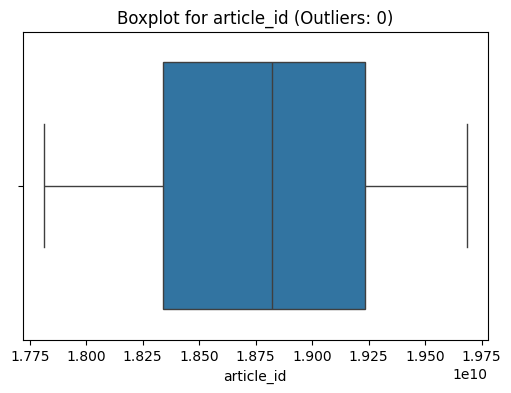

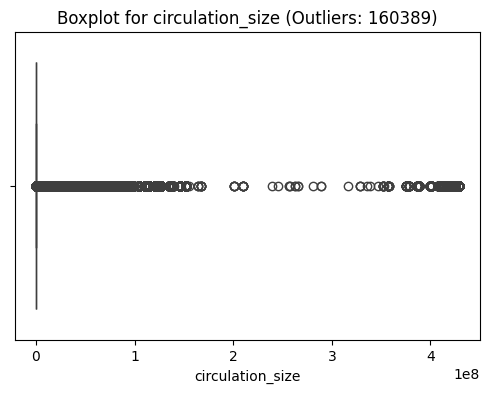

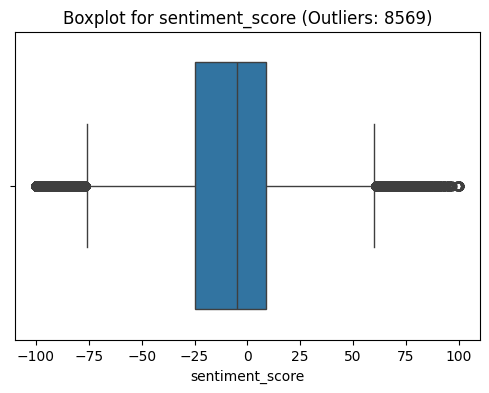

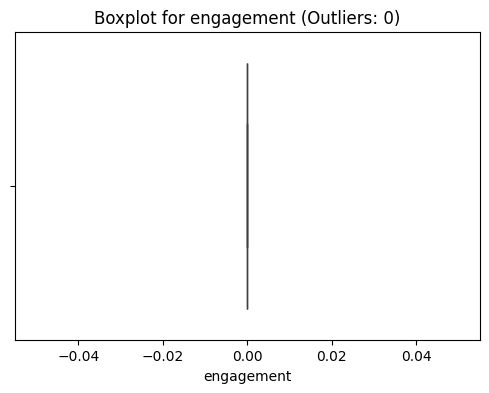

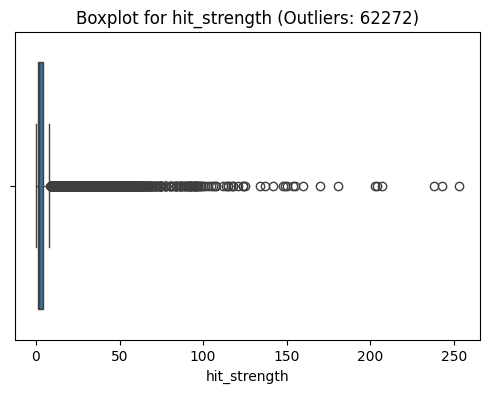

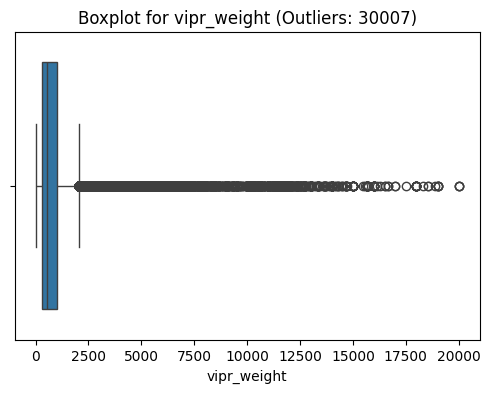

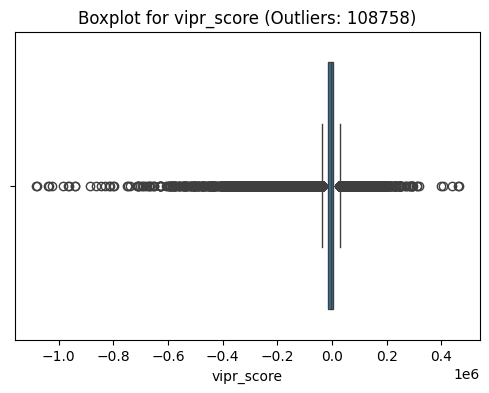

Outlier counts by column:
{'article_id': 0, 'circulation_size': 160389, 'sentiment_score': 8569, 'engagement': 0, 'hit_strength': 62272, 'vipr_weight': 30007, 'vipr_score': 108758}


In [12]:
clean_df = detect_outliers_iqr(df, numeric_cols, remove = False)

In [13]:
### remedying the outliers, doing log transformation
df_transformed = df.copy()


for col in ["vipr_weight", "hit_strength", "circulation_size"]:
    df_transformed[col + "_log"] = np.log1p(df_transformed[col])

lower = df_transformed["vipr_score"].quantile(0.01)
upper = df_transformed["vipr_score"].quantile(0.99)
df_transformed["vipr_score_clip"] = df_transformed["vipr_score"].clip(lower, upper)

print("Transformations complete. New columns created:")
print([c for c in df_transformed.columns if c.endswith("_log") or c.endswith("_clip")])

Transformations complete. New columns created:
['vipr_weight_log', 'hit_strength_log', 'circulation_size_log', 'vipr_score_clip']


## EDA

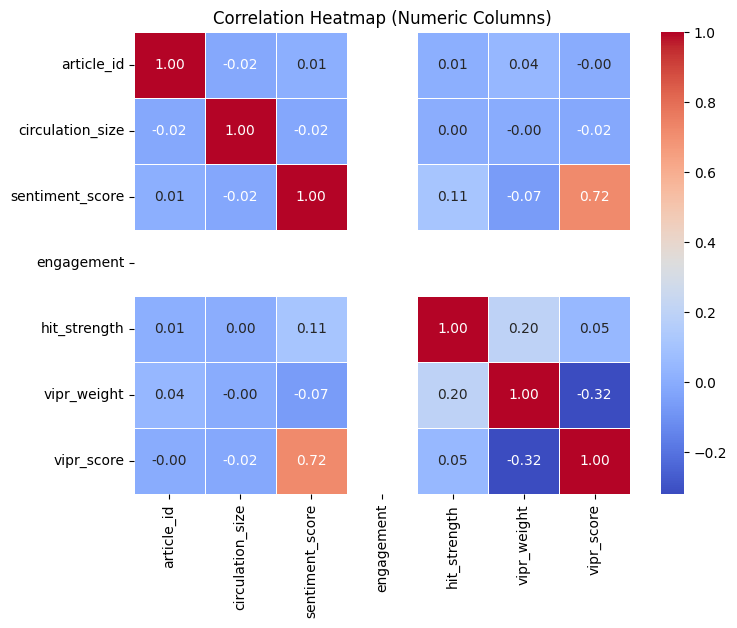

In [17]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Columns)")
plt.show()

In [21]:
### VIPR score highly correlated to sentiment scoring

In [14]:
#### Identifying 'Conversions'

df_conv = df_transformed.copy()

# Ensure the transformed columns exist
required_cols = ["circulation_size_log", "vipr_weight_log", "hit_strength_log"]
missing = [c for c in required_cols if c not in df_conv.columns]
if missing:
    raise ValueError(f"Missing transformed cols: {missing}. Re-run your transform step.")

# 25th-percentile thresholds
circ_thr     = df_conv["circulation_size_log"].quantile(0.25)
weight_thr   = df_conv["vipr_weight_log"].quantile(0.25)
strength_thr = df_conv["hit_strength_log"].quantile(0.25)

# Flag = 1 if in the top quartile on all three
df_conv["conversion_proxy"] = (
    (df_conv["circulation_size_log"] >= circ_thr) &
    (df_conv["vipr_weight_log"]   >= weight_thr) &
    (df_conv["hit_strength_log"]  >= strength_thr)
).astype(int)

print("conversion_proxy distribution:")
print(df_conv["conversion_proxy"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")


conversion_proxy distribution:
conversion_proxy
1    56.75%
0    43.25%
Name: proportion, dtype: object


In [15]:
count_1 = df_conv["conversion_proxy"].sum()
count_0 = (df_conv["conversion_proxy"] == 0).sum()

print(f"Articles qualifying as 1 (conversion proxy): {count_1}")
print(f"Articles qualifying as 0: {count_0}")
print(f"Percentage qualifying: {count_1 / len(df_conv) * 100:.2f}%")

Articles qualifying as 1 (conversion proxy): 536966
Articles qualifying as 0: 409295
Percentage qualifying: 56.75%


In [16]:
def eda_tables_dual(df: pd.DataFrame):
    """
    Build EDA tables for:
      - Top publications (article_count, avg_circulation)
      - Avg circulation by source type
      - EDA by channel (article_count, avg_circulation)
      - Daily article & circulation distribution
      - Monthly article & circulation distribution
      - Sentiment band EDA (distribution)
      - Sentiment score EDA (summary + by band)

    Returns:
      {
        "full": { <tables> },
        "conversion": { <tables> }  # only if 'conversion_proxy' in df
      }
    """

    def _build(sub_df: pd.DataFrame):
        out = {}

        # ---- time keys
        day = sub_df["load_date"].dt.date
        month = sub_df["load_date"].dt.to_period("M").dt.to_timestamp()

        # ---- 1) Top publications
        out["top_publications"] = (
            sub_df.groupby("publication_name", dropna=False)
                  .agg(article_count=("article_id", "count"),
                       avg_circulation=("circulation_size", "mean"))
                  .sort_values(["article_count","avg_circulation"], ascending=[False, False])
                  .head(25)
                  .reset_index()
        )

        # ---- 2) Avg circulation by source type
        st_col = "source_type_name" if "source_type_name" in sub_df.columns else "source_type"
        out["avg_circulation_by_source_type"] = (
            sub_df.groupby(st_col, dropna=False)
                  .agg(avg_circulation=("circulation_size","mean"),
                       median_circulation=("circulation_size","median"),
                       article_count=("article_id","count"))
                  .sort_values("avg_circulation", ascending=False)
                  .reset_index()
        )

        # ---- 3) EDA by channel (count + avg circ)
        out["by_channel"] = (
            sub_df.groupby("channel_name", dropna=False)
                  .agg(article_count=("article_id","count"),
                       avg_circulation=("circulation_size","mean"))
                  .sort_values(["article_count","avg_circulation"], ascending=[False, False])
                  .reset_index()
        )

        # ---- 4) Daily distribution (articles + total circulation)
        out["daily_distribution"] = (
            sub_df.assign(DAY=day)
                  .groupby("DAY", as_index=False)
                  .agg(article_count=("article_id","count"),
                       circulation_total=("circulation_size","sum"))
                  .sort_values("DAY")
        )

        # ---- 5) Monthly distribution (articles + total circulation)
        out["monthly_distribution"] = (
            sub_df.assign(MONTH=month)
                  .groupby("MONTH", as_index=False)
                  .agg(article_count=("article_id","count"),
                       circulation_total=("circulation_size","sum"))
                  .sort_values("MONTH")
        )

        # ---- 6) Sentiment band EDA
        out["sentiment_band_distribution"] = (
            sub_df["sentiment_band"].value_counts(dropna=False)
                .rename_axis("sentiment_band")
                .reset_index(name="count")
        )
        # with percentages
        total_rows = len(sub_df)
        if total_rows > 0:
            out["sentiment_band_distribution"]["pct"] = (
                out["sentiment_band_distribution"]["count"] / total_rows * 100
            ).round(2)

        # ---- 7) Sentiment score EDA
        # overall summary
        if "sentiment_score" in sub_df.columns:
            out["sentiment_score_summary"] = (
                sub_df["sentiment_score"].describe().to_frame("value")
            )
            # by band
            out["sentiment_score_by_band"] = (
                sub_df.groupby("sentiment_band", dropna=False)["sentiment_score"]
                      .agg(mean="mean", median="median", std="std", count="count")
                      .reset_index()
                      .sort_values("mean", ascending=False)
            )
        else:
            out["sentiment_score_summary"] = pd.DataFrame()
            out["sentiment_score_by_band"] = pd.DataFrame()

        return out

    results = {"full": _build(df)}

    # add conversion subset if available
    if "conversion_proxy" in df.columns:
        results["conversion"] = _build(df[df["conversion_proxy"] == 1].copy())

    return results


In [17]:
eda_tables_dual(df)["full"]

{'top_publications':                                   publication_name  article_count  \
 0                                      Head Topics          15225   
 1   Multidisciplinary Digital Publishing Institute           7526   
 2                                          Archyde           4182   
 3                                       Archynetys           3535   
 4                                           Medium           3315   
 5                                        ReliefWeb           2873   
 6                                       News Break           2616   
 7                                   Medical Xpress           2575   
 8                                       World News           2549   
 9                                              MSN           2399   
 10                                             AOL           2365   
 11                                            NCBI           2358   
 12                                     Newsy Today           2153   


In [18]:
tables_dual = eda_tables_dual(df_conv)
tables_dual["full"]["by_channel"].head()

,channel_name,article_count,avg_circulation
0,Web,725517,2.812122e+06
1,Broadcast,179186,2.949601e+05
2,Social,40232,1.192877e+06
3,Print,1323,6.316273e+05
4,Unknown,3,1.613333e+02


In [19]:
tables_dual["conversion"]["by_channel"].head(5)

,channel_name,article_count,avg_circulation
0,Web,459308,3.833667e+06
1,Broadcast,59695,4.604636e+05
2,Social,17293,2.388155e+06
3,Print,670,1.246085e+06


In [20]:
tables_dual["conversion"]["sentiment_score_by_band"]

,sentiment_band,mean,median,std,count
2,Positive,29.466557,26.0,11.974332,80599
1,Neutral,-1.078168,0.0,7.985886,245970
0,Negative,-34.846932,-32.0,14.581933,210397


In [21]:
def eda_visuals_matplotlib(df: pd.DataFrame, title_prefix="Dataset"):
    # ---- 0) small helpers  ----
    def barh_from_series(s: pd.Series, title: str, xlabel: str, ylabel: str):
        if s.empty: return
        plt.figure(figsize=(10, 6))
        s = s.sort_values(ascending=True)
        plt.barh(s.index.astype(str), s.values, color="skyblue")
        plt.title(f"{title_prefix}: {title}", fontsize=14)
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(axis="x", linestyle="--", alpha=0.7)
        plt.tight_layout()
        plt.show()

    def barh_from_df(df_in: pd.DataFrame, cat_col: str, val_col: str, title: str, xlabel: str, ylabel: str, top_n=15):
        if df_in.empty or cat_col not in df_in or val_col not in df_in: return
        dd = df_in[[cat_col, val_col]].dropna()
        dd = dd.groupby(cat_col)[val_col].mean().sort_values(ascending=False).head(top_n)
        barh_from_series(dd, title, xlabel, ylabel)

    def line_from_series(s: pd.Series, title: str, xlabel: str, ylabel: str):
        if s.empty: return
        plt.figure(figsize=(12, 5))
        plt.plot(s.index, s.values, marker="o", label=ylabel)
        plt.title(f"{title_prefix}: {title}", fontsize=14)
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.xticks(rotation=45, ha="right")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    def bar_from_series(s: pd.Series, title: str, xlabel: str, ylabel: str):
        if s.empty: return
        plt.figure(figsize=(12, 5))
        plt.bar(s.index.astype(str), s.values, color="orange")
        plt.title(f"{title_prefix}: {title}", fontsize=14)
        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.xticks(rotation=45, ha="right")
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    def hist1(col: str, bins=40, logscale=False, title_suffix=""):
        if col not in df: return
        x = pd.to_numeric(df[col], errors="coerce").dropna()
        if x.empty: return
        plt.figure(figsize=(8, 5))
        plt.hist(x.values, bins=bins, color="green", alpha=0.7)
        if logscale:
            plt.yscale("log")
        ttl = f"{title_prefix}: Distribution of {col}"
        if title_suffix: ttl += f" ({title_suffix})"
        plt.title(ttl, fontsize=14)
        plt.xlabel(f"{col} Value", fontsize=12)
        plt.ylabel("Frequency (Count)", fontsize=12)
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    # ---- 1) Top publications by article count ----
    if "publication_name" in df and "article_id" in df:
        top_pubs = df["publication_name"].value_counts().head(15)
        barh_from_series(top_pubs, "Top Publications by Article Count", "Article Count", "Publication Name")

    # ---- 2) Average circulation by source type ----
    st_col = "source_type_name" if "source_type_name" in df.columns else ("source_type" if "source_type" in df.columns else None)
    if st_col and "circulation_size" in df:
        barh_from_df(df, st_col, "circulation_size", "Average Circulation by Source Type", "Average Circulation (Units)", "Source Type", top_n=20)

    # ---- 3) EDA by channel (article count) ----
    if "channel_name" in df:
        top_channels = df["channel_name"].value_counts().head(15)
        barh_from_series(top_channels, "Top Channels by Article Count", "Article Count", "Channel Name")

    # ---- 4) Daily article distribution (count) ----
    if "load_date" in df and "article_id" in df:
        ld = pd.to_datetime(df["load_date"], errors="coerce")
        daily_counts = df.assign(_day=ld.dt.date).groupby("_day")["article_id"].count()
        line_from_series(daily_counts, "Daily Article Count Over Time", "Date", "Number of Articles")

    # ---- 5) Monthly article distribution (count) ----
    if "load_date" in df and "article_id" in df:
        month = pd.to_datetime(df["load_date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
        monthly_counts = df.assign(_month=month).groupby("_month")["article_id"].count()
        bar_from_series(monthly_counts, "Monthly Article Count", "Month", "Number of Articles")

    # ---- 6) Daily circulation sum ----
    if "load_date" in df and "circulation_size" in df:
        ld = pd.to_datetime(df["load_date"], errors="coerce")
        daily_circ = df.assign(_day=ld.dt.date).groupby("_day")["circulation_size"].sum()
        line_from_series(daily_circ, "Daily Circulation Volume Over Time", "Date", "Total Circulation Volume")

    # ---- 7) Monthly circulation sum ----
    if "load_date" in df and "circulation_size" in df:
        month = pd.to_datetime(df["load_date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
        monthly_circ = df.assign(_month=month).groupby("_month")["circulation_size"].sum()
        bar_from_series(monthly_circ, "Monthly Circulation Volume", "Month", "Total Circulation Volume")

    # ---- 8) Sentiment band distribution ----
    if "sentiment_band" in df:
        band_counts = df["sentiment_band"].value_counts()
        bar_from_series(band_counts, "Sentiment Band Distribution", "Sentiment Band", "Count of Articles")

    # ---- 9) Sentiment score distribution ----
    if "sentiment_score" in df:
        hist1("sentiment_score", bins=50, title_suffix="linear scale")

    for col in ["vipr_weight_log", "hit_strength_log", "circulation_size_log"]:
        if col in df.columns:
            hist1(col, bins=50, title_suffix="log-transformed")

    # Clipped vipr score
    if "vipr_score_clip" in df.columns:
        hist1("vipr_score_clip", bins=60, title_suffix="clipped (1st–99th pct)")

    # Optional: relationship between sentiment_score and vipr_score_clip
    if "vipr_score_clip" in df.columns and "sentiment_score" in df.columns:
        x = pd.to_numeric(df["vipr_score_clip"], errors="coerce")
        y = pd.to_numeric(df["sentiment_score"], errors="coerce")
        m = (~x.isna()) & (~y.isna())
        if m.any():
            plt.figure(figsize=(8, 6))
            plt.scatter(x[m].values, y[m].values, alpha=0.15, s=8, c="purple", label="Articles")
            plt.title(f"{title_prefix}: VIPR Score (clipped) vs Sentiment Score", fontsize=14)
            plt.xlabel("VIPR Score (Clipped)", fontsize=12)
            plt.ylabel("Sentiment Score", fontsize=12)
            plt.legend()
            plt.grid(True, linestyle="--", alpha=0.5)
            plt.tight_layout()
            plt.show()


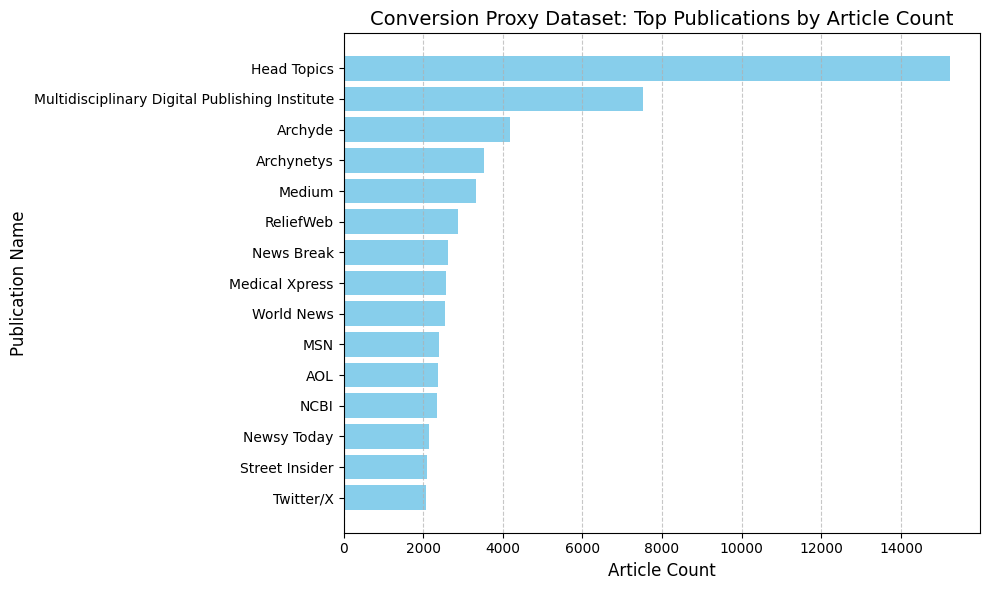

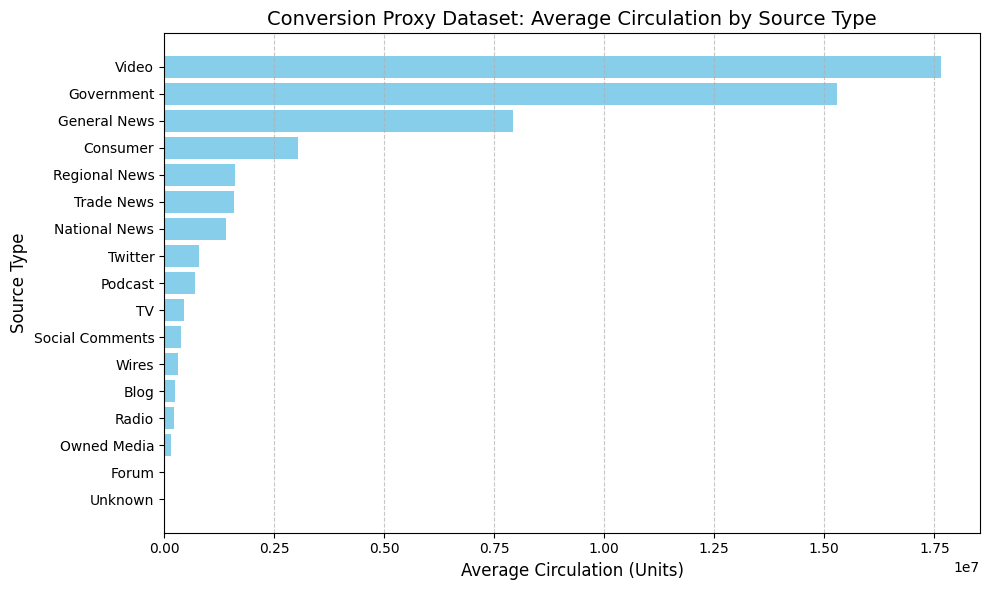

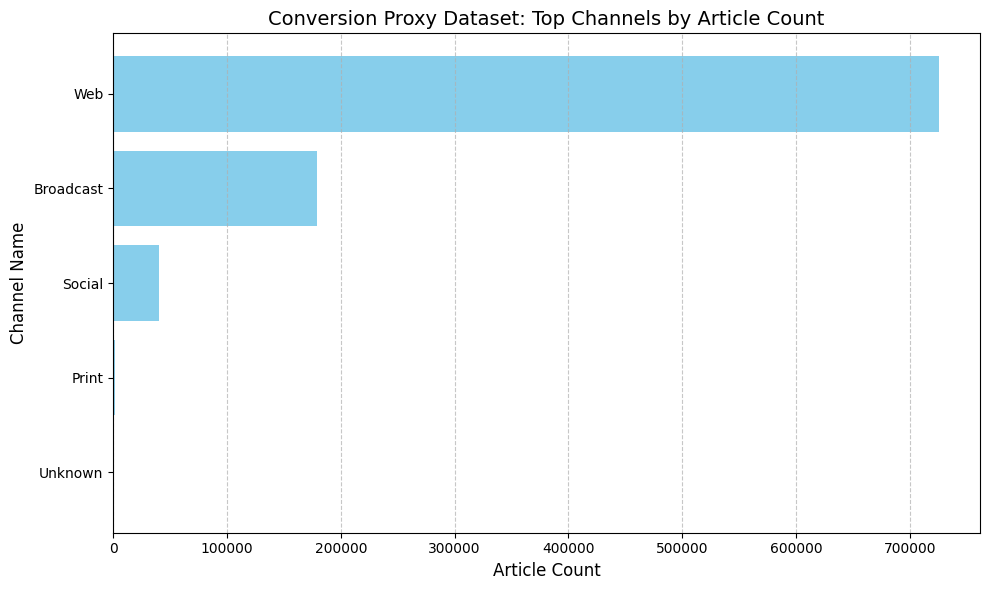

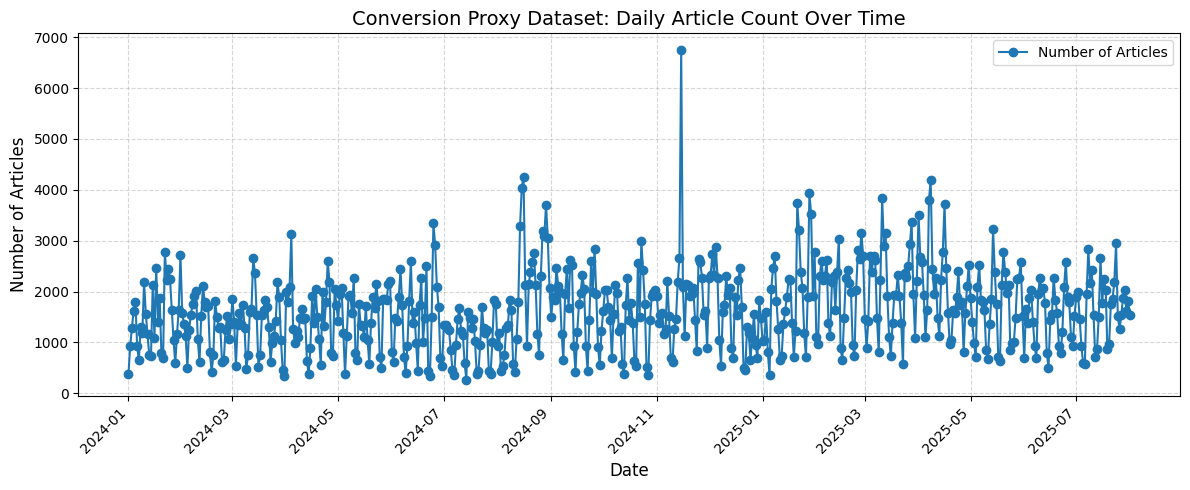

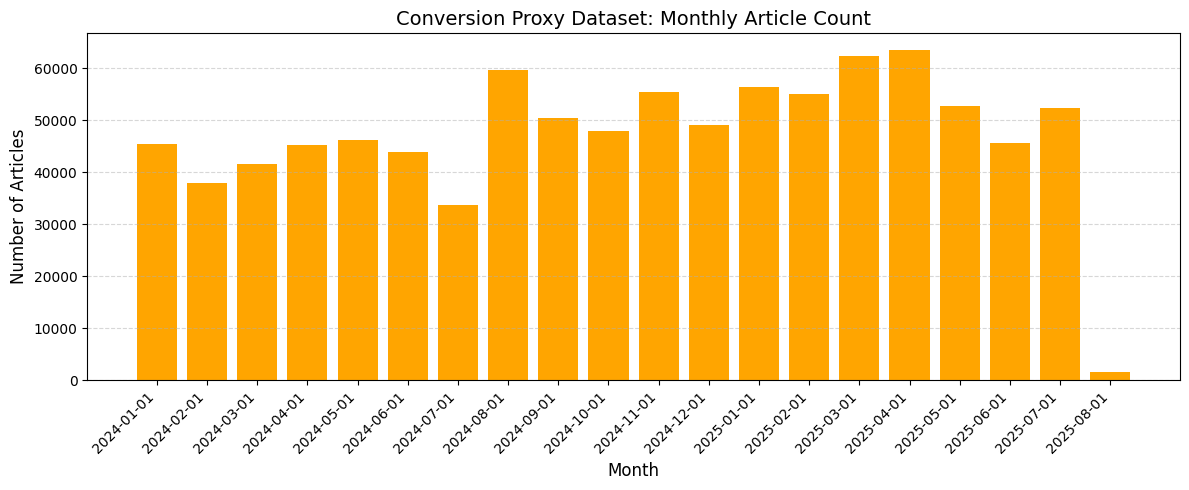

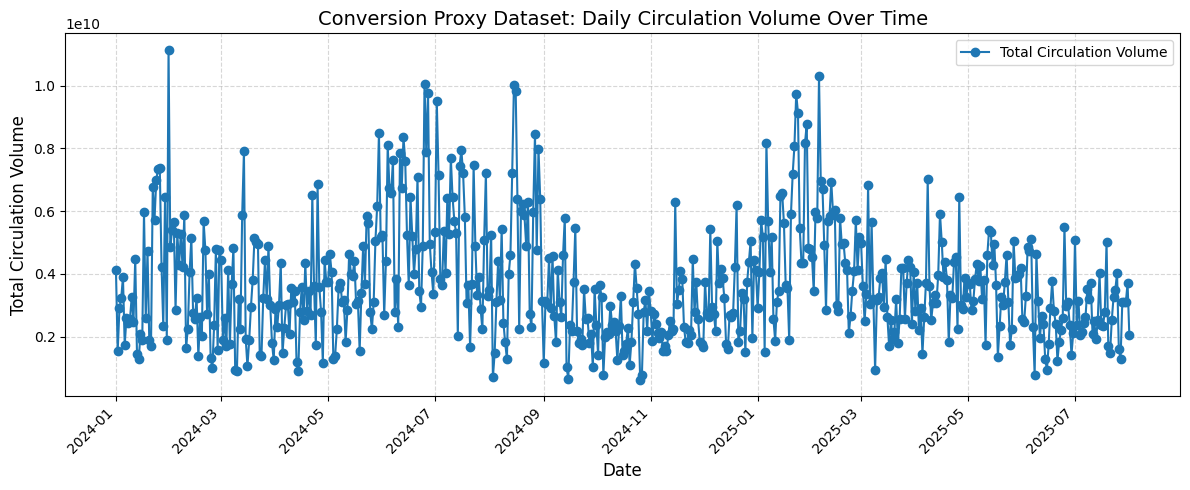

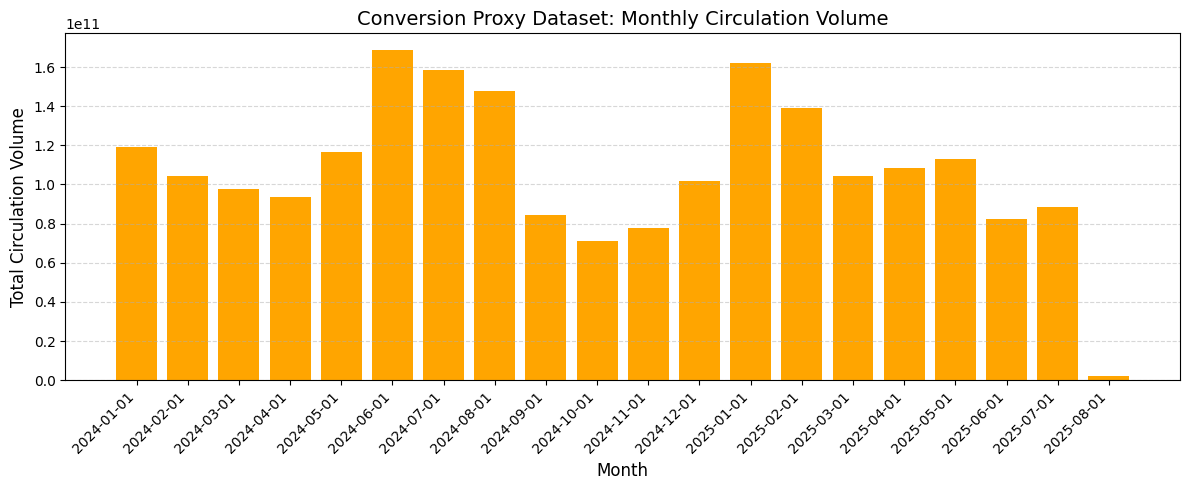

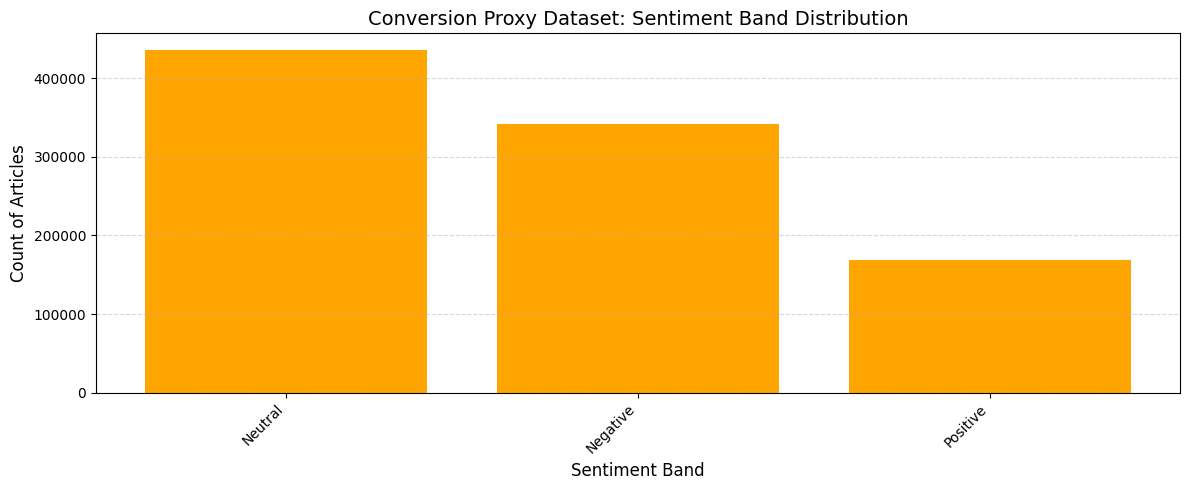

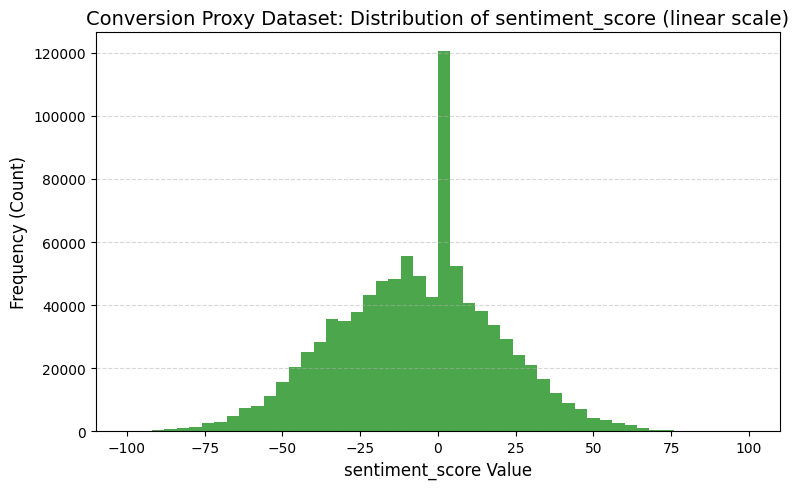

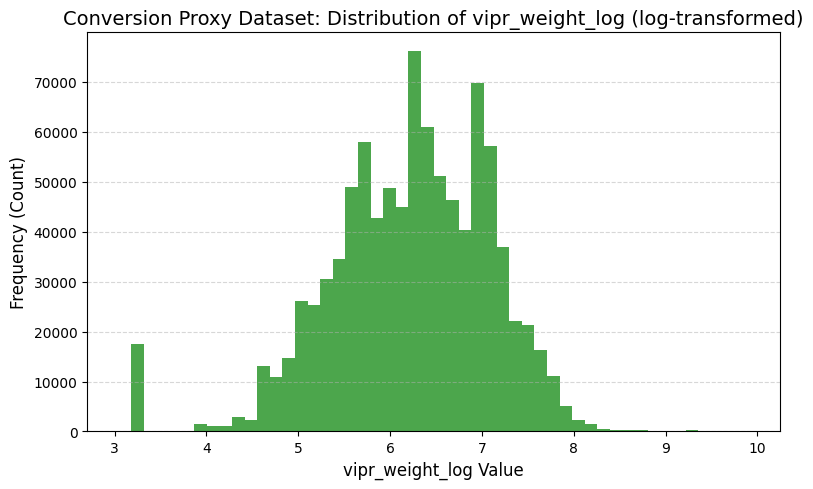

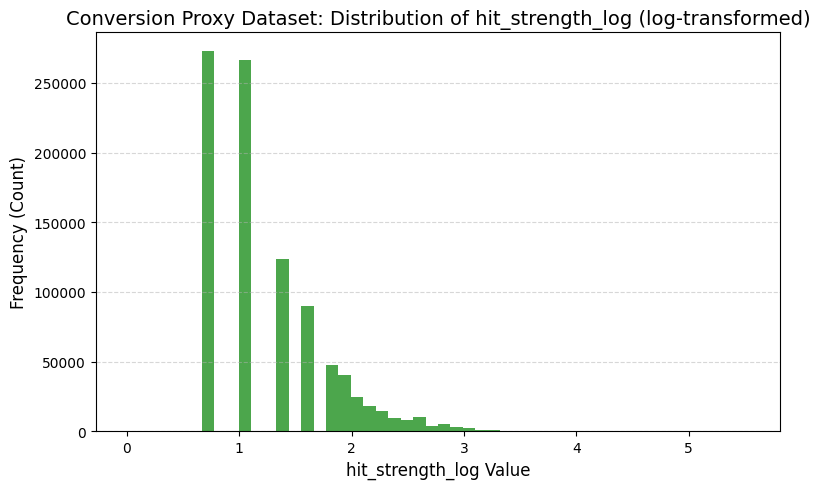

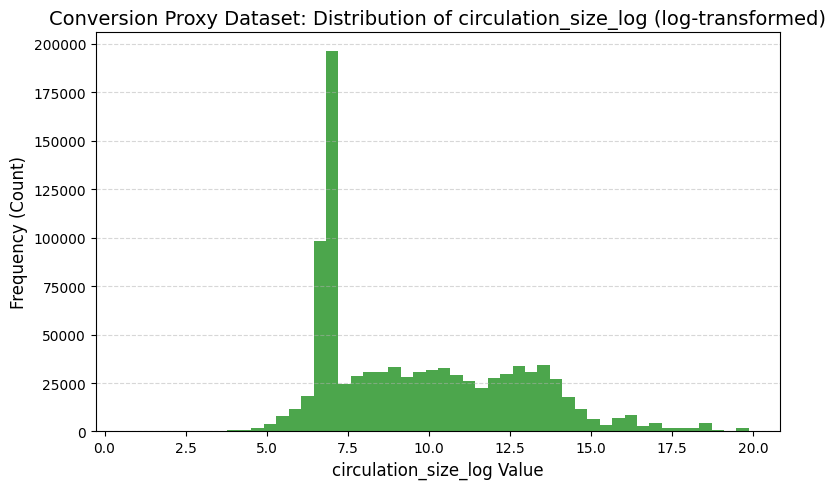

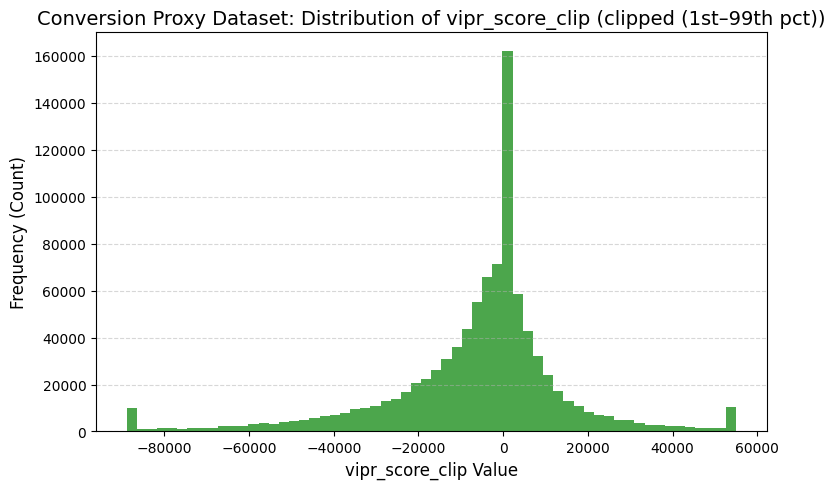

C:\Users\jasmi\AppData\Local\Temp\ipykernel_19116\668811609.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\jasmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


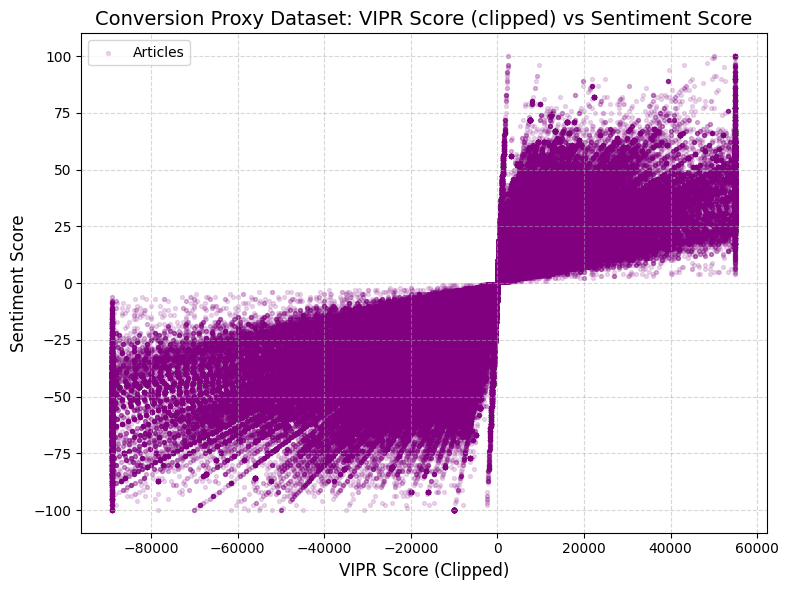

In [22]:
eda_visuals_matplotlib(df_conv, title_prefix="Conversion Proxy Dataset")

## Network Analysis EDA

In [27]:
DF = df_conv
SOURCE_COL = "source_type_name"
TOPIC_COL  = "tag_name"

WEIGHT_BY = ["circulation_size_log", "vipr_weight_log", "hit_strength_log"]
WEIGHT_WEIGHTS = None   

MIN_EDGE_WEIGHT = 0.2
MIN_TOPICS_PER_SOURCE = 2
MIN_SOURCES_PER_TOPIC = 2
USE_TFIDF = True

EDGE_KEEP_PCT_BIP = 75
EDGE_KEEP_PCT_PROJ = 70
LABEL_SOURCES_TOP = 25
LABEL_TOPICS_TOP = 8

# 1) Rank-only combiner
def _combine_rankpct(df: pd.DataFrame, cols: list[str], weights: list[float] | None = None) -> pd.Series:
    """
    Percentile-rank each column to [0,1], then take a (weighted) mean across columns.
    Robust to scale/outliers. NaNs are filled with the column's mean rank.
    """
    X = df[cols].copy().replace([np.inf, -np.inf], np.nan)
    R = X.rank(pct=True, na_option="keep")
    R = R.fillna(R.mean())
    if weights is None:
        w = np.ones(len(cols), dtype=float)
    else:
        w = np.asarray(weights, dtype=float)
    s = w.sum()
    if s == 0:
        w = np.ones(len(cols), dtype=float)
        s = w.sum()
    w = w / s
    return (R * w).sum(axis=1)

# 2) Build bipartite graph
def build_source_topic_bipartite(
    df: pd.DataFrame,
    source_col: str = "source_type_name",
    topic_col: str = "tag_name",
    weight_by: str | list[str] = "count",
    weight_weights: list[float] | None = None,
    min_edge_weight: float = 0.2,
    min_topics_per_source: int = 2,
    min_sources_per_topic: int = 2,
    drop_na: bool = True,
    use_tfidf: bool = False,
    use_sum_instead_of_mean: bool = False  
):
    assert source_col in df.columns and topic_col in df.columns, "Missing source/topic columns."
    dd = df.copy()
    if drop_na:
        dd = dd.dropna(subset=[source_col, topic_col])

    # weights
    if isinstance(weight_by, str):
        if weight_by == "count":
            agg = dd.groupby([source_col, topic_col]).size().reset_index(name="weight")
        else:
            if weight_by not in dd.columns:
                raise ValueError(f"weight_by='{weight_by}' not found in DataFrame.")
            agg = dd.groupby([source_col, topic_col])[weight_by].sum(min_count=1).reset_index(name="weight")
    else:
        # list of columns blended via rank-pct
        for c in weight_by:
            if c not in dd.columns:
                raise ValueError(f"Column '{c}' in weight_by not found in DataFrame.")
        dd["__combined_weight__"] = _combine_rankpct(dd, weight_by, weights=weight_weights)
        grp = dd.groupby([source_col, topic_col])["__combined_weight__"]
        agg = (grp.sum() if use_sum_instead_of_mean else grp.mean()).reset_index(name="weight")

    # edge threshold
    agg = agg[agg["weight"] >= min_edge_weight].copy()
    if agg.empty:
        return nx.Graph(), agg, set(), set()

    # optional TF-IDF reweighting
    if use_tfidf:
        src_tot = agg.groupby(source_col)["weight"].transform("sum")
        agg["tf"] = agg["weight"] / src_tot
        topic_src_n = agg.groupby(topic_col)[source_col].transform("nunique")
        n_sources = agg[source_col].nunique()
        agg["idf"] = np.log((n_sources + 1) / (topic_src_n + 1)) + 1
        agg["weight"] = agg["tf"] * agg["idf"]
        agg = agg[[source_col, topic_col, "weight"]]

    # degree pruning
    keep_src = set(agg.groupby(source_col)[topic_col].nunique().pipe(lambda s: s[s >= min_topics_per_source].index))
    keep_top = set(agg.groupby(topic_col)[source_col].nunique().pipe(lambda s: s[s >= min_sources_per_topic].index))
    agg = agg[agg[source_col].isin(keep_src) & agg[topic_col].isin(keep_top)]
    if agg.empty:
        return nx.Graph(), agg, set(), set()

    # build graph
    B = nx.Graph()
    B.add_nodes_from(sorted(keep_src), bipartite=0, kind="source")
    B.add_nodes_from(sorted(keep_top), bipartite=1, kind="topic")
    B.add_weighted_edges_from(agg[[source_col, topic_col, "weight"]].itertuples(index=False, name=None))
    sources = {n for n, d in B.nodes(data=True) if d.get("bipartite") == 0}
    topics  = set(B) - sources
    return B, agg, sources, topics

In [28]:
# 3) Visual helpers
def _safe_bipartite_layout(G, left_nodes):
    try:
        return nxb.layout.bipartite_layout(G, left_nodes)
    except Exception:
        return nx.spring_layout(G, seed=42)

def visualize_bipartite(B, sources, topics, title="Sources ↔ Topics (Bipartite)",
                        label_sources_top=20, label_topics_top=0, edge_keep_pct=70):
    if B.number_of_nodes() == 0:
        print("Graph is empty."); return
    w = np.array([B[u][v].get("weight", 1) for u, v in B.edges()])
    thr = np.percentile(w, 100 - edge_keep_pct) if len(w) else 1
    H = nx.Graph()
    H.add_nodes_from(B.nodes(data=True))
    H.add_edges_from([(u, v, d) for u, v, d in B.edges(data=True) if d.get("weight", 1) >= thr])
    H.remove_nodes_from([n for n in list(H.nodes) if H.degree(n) == 0])
    if H.number_of_nodes() == 0:
        print("No nodes after pruning."); return
    comps = list(nx.connected_components(H))
    H = H.subgraph(max(comps, key=len)).copy()

    left = [n for n in H.nodes if n in sources]
    right = [n for n in H.nodes if n in topics]
    if not left or not right:
        left = [n for n, d in H.nodes(data=True) if d.get("bipartite") == 0] or left
        right = [n for n, d in H.nodes(data=True) if d.get("bipartite") == 1] or right

    pos = _safe_bipartite_layout(H, left)
    strength = {n: sum(H[n][nbr].get("weight", 1) for nbr in H.neighbors(n)) for n in H.nodes()}
    size_map = {n: 80 + 12*np.log1p(s) for n, s in strength.items()}
    ewidths = [0.6 + np.log1p(H[u][v].get("weight", 1)) for u, v in H.edges()]

    plt.figure(figsize=(12, 8))
    nx.draw_networkx_edges(H, pos, width=ewidths, alpha=0.35)
    src_nodes = nx.draw_networkx_nodes(H, pos, nodelist=left, node_color="#3b82f6",
                                       node_size=[size_map[n] for n in left], label="Sources")
    top_nodes = nx.draw_networkx_nodes(H, pos, nodelist=right, node_color="#a78bfa",
                                       node_size=[size_map[n] for n in right], label="Topics")

    degH = dict(H.degree())
    top_src = {n for n, _ in sorted(((n, degH.get(n, 0)) for n in left), key=lambda x: x[1], reverse=True)[:label_sources_top]}
    top_top = {n for n, _ in sorted(((n, degH.get(n, 0)) for n in right), key=lambda x: x[1], reverse=True)[:label_topics_top]}
    nx.draw_networkx_labels(H, pos, labels={n:n for n in (top_src | top_top)}, font_size=8)

    plt.title(title)
    plt.legend(handles=[src_nodes, top_nodes], scatterpoints=1, fontsize=9, frameon=False, loc="upper left")
    plt.axis("off"); plt.tight_layout(); plt.show()

def project_sources(B, sources, method="overlap"):
    if method == "weighted": return nxb.weighted_projected_graph(B, sources, weight="weight")
    if method == "jaccard":  return nxb.jaccard_weighted_projected_graph(B, sources)
    return nxb.overlap_weighted_projected_graph(B, sources, jaccard=False)

def project_topics(B, topics, method="overlap"):
    if method == "weighted": return nxb.weighted_projected_graph(B, topics, weight="weight")
    if method == "jaccard":  return nxb.jaccard_weighted_projected_graph(B, topics)
    return nxb.overlap_weighted_projected_graph(B, topics, jaccard=False)

def visualize_projection(G, title="Projection", label_top=20, edge_keep_pct=70):
    if G.number_of_nodes() == 0:
        print("Projection is empty."); return
    w = np.array([G[u][v].get("weight", 1) for u, v in G.edges()])
    thr = np.percentile(w, 100 - edge_keep_pct) if len(w) else 1
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    H.add_edges_from([(u, v, d) for u, v, d in G.edges(data=True) if d.get("weight", 1) >= thr])
    H.remove_nodes_from([n for n in list(H.nodes) if H.degree(n) == 0])
    if H.number_of_nodes() == 0:
        print("No nodes after pruning."); return
    pos = nx.spring_layout(H, seed=42, k=1/np.sqrt(max(1, H.number_of_nodes())))
    strength = {n: sum(H[n][nbr].get("weight", 1) for nbr in H.neighbors(n)) for n in H.nodes()}
    sizes = [120 + 14*np.log1p(strength[n]) for n in H.nodes()]
    ewidths = [0.6 + np.log1p(H[u][v].get("weight", 1)) for u, v in H.edges()]
    plt.figure(figsize=(11, 8))
    nx.draw_networkx_edges(H, pos, width=ewidths, alpha=0.35)
    nx.draw_networkx_nodes(H, pos, node_size=sizes)
    top_nodes = {n for n, _ in sorted(strength.items(), key=lambda x: x[1], reverse=True)[:label_top]}
    nx.draw_networkx_labels(H, pos, labels={n:n for n in top_nodes}, font_size=9)
    plt.title(title); plt.axis("off"); plt.tight_layout(); plt.show()

edges kept in agg: 76
sources: 16 topics: 6


,source_type_name,tag_name,weight
44,Regional News,Last Smoke Campaign,0.568121
1,Blog,Last Smoke Campaign,0.406157
78,Wires,State Healthcare Funding,0.372242
13,Forum,World Health Leadership,0.352036
12,Forum,Public Health,0.351374
50,Social Comments,NHS Reform,0.338797
11,Forum,Health Campaign,0.333664
7,Consumer,NHS Reform,0.318473
73,Video,State Healthcare Funding,0.316558
29,Owned Media,Health Campaign,0.315365


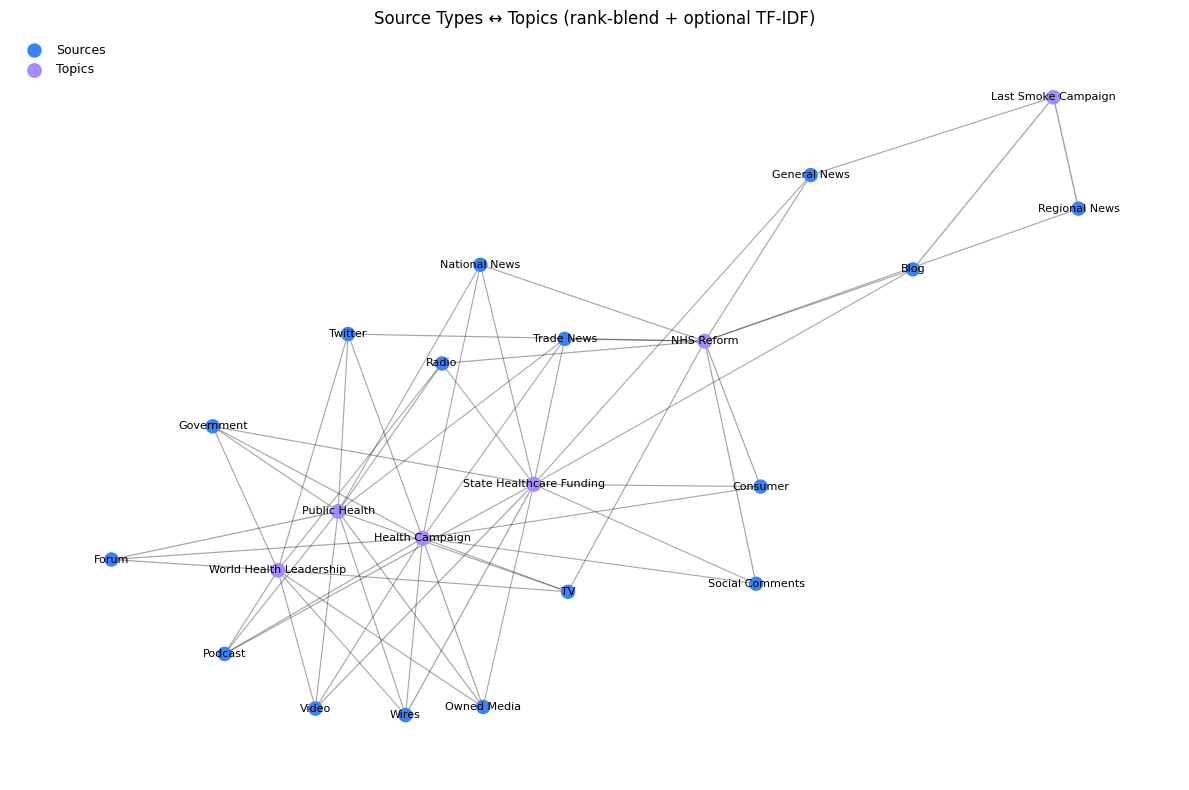

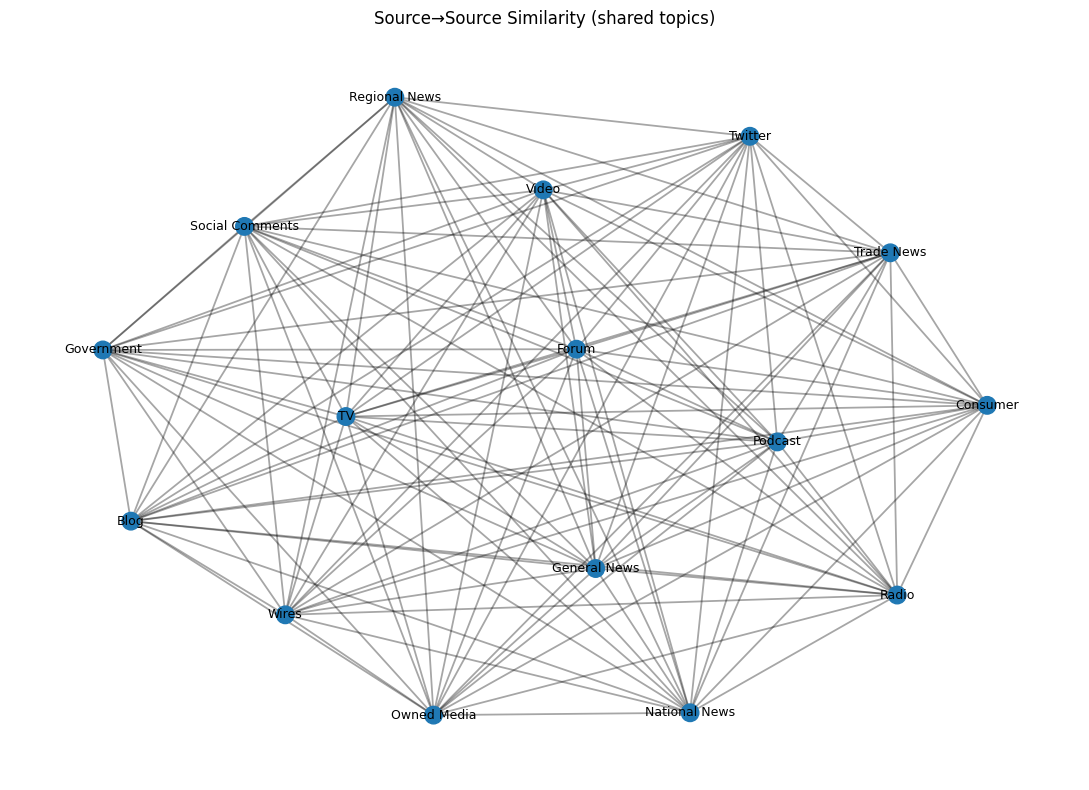

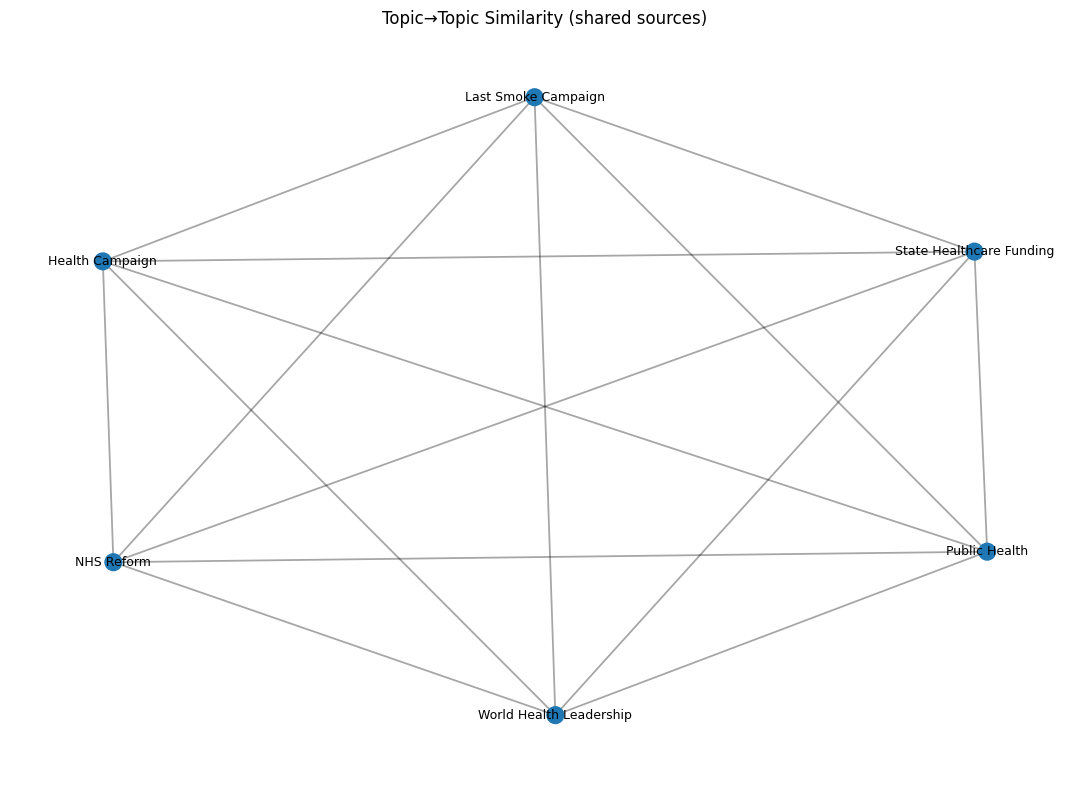

In [30]:
#4) Build + visualize + lists
B, agg, sources, topics = build_source_topic_bipartite(
    DF,
    source_col=SOURCE_COL,
    topic_col=TOPIC_COL,
    weight_by=WEIGHT_BY,
    weight_weights=WEIGHT_WEIGHTS,
    min_edge_weight=MIN_EDGE_WEIGHT,
    min_topics_per_source=MIN_TOPICS_PER_SOURCE,
    min_sources_per_topic=MIN_SOURCES_PER_TOPIC,
    use_tfidf=USE_TFIDF,
    use_sum_instead_of_mean=False
)

print("edges kept in agg:", len(agg))
print("sources:", len(sources), "topics:", len(topics))
display(agg.sort_values("weight", ascending=False).head(15))

# Auto-relax if everything was pruned
if len(agg)==0 or len(sources)==0 or len(topics)==0:
    print("Nothing left after thresholds → relaxing filters...")
    B, agg, sources, topics = build_source_topic_bipartite(
        DF, SOURCE_COL, TOPIC_COL,
        weight_by=WEIGHT_BY, weight_weights=WEIGHT_WEIGHTS,
        min_edge_weight=0.0, min_topics_per_source=1, min_sources_per_topic=1,
        use_tfidf=False, use_sum_instead_of_mean=False
    )
    print("RELAXED → edges:", len(agg), "sources:", len(sources), "topics:", len(topics))

# Visuals
visualize_bipartite(B, sources, topics,
    title="Source Types ↔ Topics (rank-blend + optional TF-IDF)",
    label_sources_top=LABEL_SOURCES_TOP,
    label_topics_top=LABEL_TOPICS_TOP,
    edge_keep_pct=EDGE_KEEP_PCT_BIP
)

Gs = project_sources(B, sources, method="overlap")
visualize_projection(Gs, title="Source→Source Similarity (shared topics)", label_top=25, edge_keep_pct=EDGE_KEEP_PCT_PROJ)

Gt = project_topics(B, topics, method="overlap")
visualize_projection(Gt, title="Topic→Topic Similarity (shared sources)", label_top=25, edge_keep_pct=EDGE_KEEP_PCT_PROJ)



In [31]:
edge_table = agg.sort_values("weight", ascending=False).reset_index(drop=True)
display(edge_table.head(25))

,source_type_name,tag_name,weight
0,Regional News,Last Smoke Campaign,0.568121
1,Blog,Last Smoke Campaign,0.406157
2,Wires,State Healthcare Funding,0.372242
3,Forum,World Health Leadership,0.352036
4,Forum,Public Health,0.351374
5,Social Comments,NHS Reform,0.338797
6,Forum,Health Campaign,0.333664
7,Consumer,NHS Reform,0.318473
8,Video,State Healthcare Funding,0.316558
9,Owned Media,Health Campaign,0.315365


In [32]:
### Top Topic per Source
def top_k_topics_per_source(agg: pd.DataFrame, source_col=SOURCE_COL, topic_col=TOPIC_COL, k=10) -> pd.DataFrame:
    if agg.empty: return agg
    return (agg.sort_values(["weight"], ascending=False)
              .groupby(source_col, group_keys=False)
              .head(k)
              .reset_index(drop=True))

display(top_k_topics_per_source(agg, k=8).head(30))


,source_type_name,tag_name,weight
0,Regional News,Last Smoke Campaign,0.568121
1,Blog,Last Smoke Campaign,0.406157
2,Wires,State Healthcare Funding,0.372242
3,Forum,World Health Leadership,0.352036
4,Forum,Public Health,0.351374
5,Social Comments,NHS Reform,0.338797
6,Forum,Health Campaign,0.333664
7,Consumer,NHS Reform,0.318473
8,Video,State Healthcare Funding,0.316558
9,Owned Media,Health Campaign,0.315365


In [33]:
### Top Sources per Topic (ranking within each topic)
def top_k_sources_per_topic(agg: pd.DataFrame, source_col=SOURCE_COL, topic_col=TOPIC_COL, k=10) -> pd.DataFrame:
    if agg.empty: return agg
    return (agg.sort_values(["weight"], ascending=False)
              .groupby(topic_col, group_keys=False)
              .head(k)
              .reset_index(drop=True))

display(top_k_sources_per_topic(agg, k=8).head(30))

,source_type_name,tag_name,weight
0,Regional News,Last Smoke Campaign,0.568121
1,Blog,Last Smoke Campaign,0.406157
2,Wires,State Healthcare Funding,0.372242
3,Forum,World Health Leadership,0.352036
4,Forum,Public Health,0.351374
5,Social Comments,NHS Reform,0.338797
6,Forum,Health Campaign,0.333664
7,Consumer,NHS Reform,0.318473
8,Video,State Healthcare Funding,0.316558
9,Owned Media,Health Campaign,0.315365


In [34]:
# Strength tables (weighted degree)
def _node_strength(G):
    return {n: sum(G[n][nbr].get("weight",1) for nbr in G.neighbors(n)) for n in G.nodes()}
if B.number_of_nodes() > 0:
    S = _node_strength(B)
    display(pd.Series({n:s for n,s in S.items() if n in sources}, name="strength")
              .sort_values(ascending=False).head(25).to_frame())
    display(pd.Series({n:s for n,s in S.items() if n in topics},  name="strength")
              .sort_values(ascending=False).head(25).to_frame())

,strength
Regional News,1.461508
Blog,1.366885
General News,1.301070
Social Comments,1.156399
Consumer,1.151910
National News,1.148702
Trade News,1.146348
Radio,1.143112
Twitter,1.138822
TV,1.128086


,strength
Health Campaign,3.748227
Public Health,3.630320
State Healthcare Funding,3.471337
World Health Leadership,3.458884
NHS Reform,2.900287
Last Smoke Campaign,1.260590


In [35]:
### Source -> Source (From Visual Above)
pairs_src = (pd.DataFrame([(u, v, d.get("weight", 1)) for u, v, d in Gs.edges(data=True)],
                          columns=["source_u", "source_v", "weight"])
               .sort_values("weight", ascending=False))
display(pairs_src.head(25))

,source_u,source_v,weight
0,Twitter,Consumer,1.0
1,Twitter,Regional News,1.0
2,Twitter,Radio,1.0
3,Twitter,Blog,1.0
4,Twitter,Forum,1.0
5,Twitter,Podcast,1.0
6,Twitter,Owned Media,1.0
7,Twitter,Wires,1.0
8,Twitter,Trade News,1.0
9,Twitter,Government,1.0


In [36]:
### Topic -> Topic (From Visual)
pairs_topic = (pd.DataFrame([(u, v, d.get("weight", 1)) for u, v, d in Gt.edges(data=True)],
                            columns=["topic_u", "topic_v", "weight"])
                 .sort_values("weight", ascending=False))
display(pairs_topic.head(25))

,topic_u,topic_v,weight
0,Last Smoke Campaign,Public Health,1.0
1,Last Smoke Campaign,World Health Leadership,1.0
2,Last Smoke Campaign,NHS Reform,1.0
3,Last Smoke Campaign,State Healthcare Funding,1.0
4,Last Smoke Campaign,Health Campaign,1.0
5,Public Health,World Health Leadership,1.0
6,Public Health,NHS Reform,1.0
7,Public Health,State Healthcare Funding,1.0
8,Public Health,Health Campaign,1.0
9,World Health Leadership,NHS Reform,1.0


### Keyword EDA Analysis

In [37]:
STOP = set(stopwords.words("english"))
LEMM = WordNetLemmatizer()

def preprocess_article_text_nltk(text: str) -> list[str]:
    """
    Lowercase → strip non-letters → tokenize by whitespace → remove stopwords/short tokens → lemmatize (noun).
    Keeps it lightweight for Python 3.13 compatibility (no POS tag requirement).
    """
    if not isinstance(text, str) or not text:
        return []
    txt = text.lower()
    txt = re.sub(r"[^a-z\s]", " ", txt)     
    toks = [t for t in txt.split() if len(t) > 2 and t not in STOP]
    
    toks = [LEMM.lemmatize(t) for t in toks]
    return toks

In [ ]:
def build_tokens(df: pd.DataFrame, body_col: str = "article_body") -> pd.DataFrame:
    if body_col not in df.columns:
        raise KeyError(f"Column '{body_col}' not found in DataFrame.")
    out = df.copy()
    out["tokens"] = out[body_col].fillna("").apply(preprocess_article_text_nltk)
    out["keyword_counts"] = out["tokens"].apply(lambda toks: Counter(toks))
    return out

df_conv = build_tokens(df_conv, body_col="article_body")

In [ ]:
### keyword frequency table 
def keyword_frequency_table(df: pd.DataFrame, tokens_col: str = "tokens") -> pd.DataFrame:
    if tokens_col not in df.columns:
        raise KeyError(f"Column '{tokens_col}' not found in DataFrame.")
    kw = (df.explode(tokens_col)
            .groupby(tokens_col)
            .size()
            .reset_index(name="frequency")
            .sort_values("frequency", ascending=False)
            .rename(columns={tokens_col: "keyword"}))
    return kw

keywords_df = keyword_frequency_table(df_conv)
display(keywords_df.head(25))

In [ ]:
### keyword co-occurence list
def keyword_cooccurrence_edges(df: pd.DataFrame, tokens_col: str = "tokens", min_co: int = 2) -> pd.DataFrame:
    """
    Builds edges between keywords that co-occur in the same article.
    Each article contributes at most one count per keyword pair (set() ensures uniqueness per article).
    """
    rows = []
    for toks in df[tokens_col].dropna():
        uniq = sorted(set(toks))
        rows.extend((a, b) for a, b in combinations(uniq, 2))
    if not rows:
        return pd.DataFrame(columns=["kw1", "kw2", "weight"])
    edges = (pd.DataFrame(rows, columns=["kw1", "kw2"])
               .value_counts()
               .reset_index(name="weight")
               .sort_values("weight", ascending=False))
    # prune weak edges
    edges = edges[edges["weight"] >= min_co].reset_index(drop=True)
    return edges

edges_kw = keyword_cooccurrence_edges(df_conv, tokens_col="tokens", min_co=2)
display(edges_kw.head(25))
print("keywords:", keywords_df.shape[0], "| co-occurrence edges:", edges_kw.shape[0])

In [ ]:
### building keyword graphs 
def build_keyword_graph(edges_kw: pd.DataFrame, min_weight: int = 2) -> nx.Graph:
    """
    edges_kw columns: ['kw1','kw2','weight']
    Creates an undirected weighted graph of keyword co-occurrence.
    """
    required = {"kw1","kw2","weight"}
    if not required.issubset(edges_kw.columns):
        raise ValueError(f"edges_kw must have columns {required}")
    df = edges_kw.copy()
    df = df[df["weight"] >= min_weight]
    G = nx.Graph()
    G.add_weighted_edges_from(df[["kw1","kw2","weight"]].itertuples(index=False, name=None))
    return G

In [ ]:
### visualizing the graphs 
def visualize_keyword_graph(
    G: nx.Graph,
    title: str = "Keyword Co-occurrence Network",
    label_top: int = 30,
    edge_keep_pct: int = 70,      # keep strongest X% edges by weight
    top_nodes_by: str = "strength" # "strength" (weighted degree) | "degree"
):
    if G.number_of_nodes() == 0:
        print("Graph is empty."); return

    # keep strongest edges by percentile
    w = np.array([G[u][v].get("weight", 1) for u, v in G.edges()])
    thr = np.percentile(w, 100 - edge_keep_pct) if len(w) else 1
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    H.add_edges_from([(u, v, d) for u, v, d in G.edges(data=True) if d.get("weight", 1) >= thr])
    H.remove_nodes_from([n for n in list(H.nodes) if H.degree(n) == 0])
    if H.number_of_nodes() == 0:
        print("No nodes after pruning."); return

    # largest connected component
    comps = list(nx.connected_components(H))
    H = H.subgraph(max(comps, key=len)).copy()

    # node sizes by weighted degree (“strength”)
    strength = {n: sum(H[n][nbr].get("weight", 1) for nbr in H.neighbors(n)) for n in H.nodes()}
    degree = dict(H.degree())
    size_map = {n: 120 + 14*np.log1p(strength.get(n, 1)) for n in H.nodes()}
    ewidths = [0.6 + np.log1p(H[u][v].get("weight", 1)) for u, v in H.edges()]

    # layout
    pos = nx.spring_layout(H, seed=42, k=1/np.sqrt(max(1, H.number_of_nodes())))

    plt.figure(figsize=(12, 9))
    nx.draw_networkx_edges(H, pos, width=ewidths, alpha=0.35)
    nx.draw_networkx_nodes(H, pos, node_size=[size_map[n] for n in H.nodes()])

    # labels: top nodes by chosen metric
    if top_nodes_by == "degree":
        rank = sorted(degree.items(), key=lambda x: x[1], reverse=True)
    else:
        rank = sorted(strength.items(), key=lambda x: x[1], reverse=True)
    top_nodes = {n for n, _ in rank[:label_top]}
    nx.draw_networkx_labels(H, pos, labels={n: n for n in top_nodes}, font_size=9)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
### Top Edges, Top Keywords by strength
def keyword_lists(G: nx.Graph, edges_kw: pd.DataFrame, top_n: int = 25):
    # strongest edges (by weight)
    edge_table = (edges_kw.sort_values("weight", ascending=False)
                           .head(top_n)
                           .reset_index(drop=True))

    # node strength (weighted degree)
    strength = pd.Series({n: sum(G[n][nbr].get("weight",1) for nbr in G.neighbors(n)) for n in G.nodes()}, name="strength")
    top_strength = strength.sort_values(ascending=False).head(top_n).to_frame()

    # classic centralities (unweighted degree & betweenness on giant component)
    if G.number_of_nodes() > 0 and G.number_of_edges() > 0:
        comps = list(nx.connected_components(G))
        H = G.subgraph(max(comps, key=len)).copy()
        deg = pd.Series(dict(H.degree()), name="degree").sort_values(ascending=False).head(top_n).to_frame()
        btw = pd.Series(nx.betweenness_centrality(H, normalized=True), name="betweenness") \
                .sort_values(ascending=False).head(top_n).to_frame()
    else:
        deg = pd.DataFrame(columns=["degree"])
        btw = pd.DataFrame(columns=["betweenness"])

    return edge_table, top_strength, deg, btw

In [ ]:
### color-coding communities
def keyword_communities(G: nx.Graph, min_size: int = 5):
    if G.number_of_nodes() == 0:
        return {}
    # greedy modularity communities (no extra deps)
    comms = list(community.greedy_modularity_communities(G))
    # keep only communities with at least min_size
    return {i: sorted(list(c)) for i, c in enumerate(c for c in comms if len(c) >= min_size)}

In [ ]:
G_kw = build_keyword_graph(edges_kw, min_weight=2)
print("keywords:", G_kw.number_of_nodes(), "| edges:", G_kw.number_of_edges())

# 2) Visualize (tune these like you did for Source→Topic)
visualize_keyword_graph(
    G_kw,
    title="Keyword Co-occurrence (min_weight=2, top edges kept)",
    label_top=30,
    edge_keep_pct=75,         # keep strongest 75% edges → prune 25% weakest
    top_nodes_by="strength"   # or "degree"
)

# 3) Lists (tables) like before
edge_table, top_strength, deg_table, btw_table = keyword_lists(G_kw, edges_kw, top_n=25)
display(edge_table.head(25))      # strongest keyword pairs
display(top_strength.head(25))    # most influential keywords by weighted degree
display(deg_table.head(25))       # highest-degree keywords
display(btw_table.head(25))       # highest-betweenness keywords

# 4) (Optional) Communities
comms = keyword_communities(G_kw, min_size=5)
for cid, members in comms.items():
    print(f"Community {cid} (n={len(members)}):", ", ".join(members[:15]), "...")